In [1]:
# Install CloudDrift
!pip install -q clouddrift

# Install Cartopy
!pip install -q cartopy

In [2]:
# Import required libraries
import clouddrift as cd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from clouddrift.datasets import gdp6h
from clouddrift.ragged import subset
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Load the 6 hourly Global Drifter Program dataset
ds = gdp6h()
ds

<xarray.Dataset> Size: 2GB
Dimensions:                (traj: 28728, obs: 48887074)
Coordinates:
    id                     (traj) int64 230kB ...
    time                   (obs) datetime64[ns] 391MB ...
Dimensions without coordinates: traj, obs
Data variables: (12/48)
    BuoyTypeManufacturer   (traj) <U20 2MB ...
    BuoyTypeSensorArray    (traj) <U20 2MB ...
    CurrentProgram         (traj) float64 230kB ...
    DeployingCountry       (traj) <U20 2MB ...
    DeployingShip          (traj) <U20 2MB ...
    DeploymentComments     (traj) <U20 2MB ...
    ...                     ...
    start_lon              (traj) float32 115kB ...
    temp                   (obs) float32 196MB ...
    typebuoy               (traj) |S10 287kB ...
    typedeath              (traj) int8 29kB ...
    ve                     (obs) float32 196MB ...
    vn                     (obs) float32 196MB ...
Attributes: (12/18)
    Conventions:          CF-1.6
    acknowledgement:      Lumpkin, Rick; Centurioni, Luca (2019). NOAA Global...
    contributor_name:     NOAA Global Drifter Program
    contributor_role:     Data Acquisition Center
    date_created:         2026-04-20T20:18:51.793217
    doi:                  10.25921/7ntx-z961
    ...                   ...
    publisher_name:       GDP Drifter DAC
    publisher_url:        https://www.aoml.noaa.gov/phod/gdp
    summary:              Global Drifter Program six-hourly data
    time_coverage_end:    2025-06-12:06:00:00Z
    time_coverage_start:  1979-02-15:00:00:00Z
    title:                Global Drifter Program drifting buoy collection

In [3]:
# -------------------------------------------------------------------
# AGGREGATING DATA BY QUARTERS (Q1–Q4 pooled across all years)
# -------------------------------------------------------------------
rowsize = ds['rowsize'].values
traj_id = ds['id'].values

obs_id = np.repeat(traj_id, rowsize)
assert len(obs_id) == ds.sizes['obs']
time = pd.to_datetime(ds['time'].values)
obs_df = pd.DataFrame({'id': obs_id, 'time': time})

# Assign year and quarter to each observation
obs_df['year'] = obs_df['time'].dt.year
obs_df['quarter'] = obs_df['time'].dt.quarter   # 1-4

# Grouping by quarters
by_quarter = (
    obs_df.groupby('quarter')
    .agg(obs=('id', 'size'), n_drifters=('id', 'nunique'))
    .reset_index()
    .rename(columns={
        'quarter': 'Quarter',
        'obs': 'Observations',
        'n_drifters': 'Unique Drifters',
    })
)

print("\n=== Observations and drifters by quarter ===")
print(by_quarter.to_string(index=False, formatters={
    'Observations': '{:,}'.format,
    'Unique Drifters': '{:,}'.format,
}))


=== Observations and drifters by quarter ===
 Quarter Observations Unique Drifters
       1   11,948,084          23,084
       2   12,030,535          22,440
       3   12,303,650          22,938
       4   12,604,805          23,389


In [4]:
# LAT and LON of full North Atlantic Ocean Basin
LAT_MIN, LAT_MAX = 10.0, 45.0
LON_MIN, LON_MAX = -80.0, -20.0
region_name = "North Atlantic Ocean Basin"

In [5]:
#------------------------------------------
# DATA WRANGLING
#------------------------------------------
ds = gdp6h()

# Extract lats and lons
lats = ds['lat'].values
lons = ds['lon'].values

# Get observation within required region
mask = (lats >= LAT_MIN) & (lats <= LAT_MAX) & \
       (lons >= LON_MIN) & (lons <= LON_MAX)

# Duplicates each ID by its corresponding 'rowsize' count
obs_ids = np.repeat(ds['id'].values, ds['rowsize'].values)

# Slice the arrays to filter all 8 core variables
filtered_lats = lats[mask]
filtered_lons = lons[mask]
filtered_ids = obs_ids[mask]
filtered_times = ds['time'].values[mask]
filtered_ve = ds['ve'].values[mask]
filtered_vn = ds['vn'].values[mask]
filtered_temp = ds['temp'].values[mask]
filtered_drogue = ds['drogue_status'].values[mask]

# Build the DataFrame
df = pd.DataFrame({
    'id': filtered_ids,
    'time': filtered_times,
    'lat': filtered_lats,
    'lon': filtered_lons,
    've': filtered_ve,
    'vn': filtered_vn,
    'temp': filtered_temp,
    'drogue': filtered_drogue
})

# Sorting by id and then by time
df = df.sort_values(by=['id', 'time']).reset_index(drop=True)

print(f"Number of Obervations: {len(df)}")
print(f'Number of drifters: {df['id'].nunique()}')

# -------------------------------------------------------------------
# AGGREGATING OBSERVATIONS BY QUARTERS
# -------------------------------------------------------------------
# Assign time and year
df['year'] = df['time'].dt.year
df['quarter'] = df['time'].dt.quarter

# Group by quarters
by_quarter = (
    df.groupby('quarter')
    .agg(obs=('id', 'size'), n_drifters=('id', 'nunique'))
    .reset_index()
    .rename(columns={
        'quarter': 'Quarter',
        'obs': 'Observations',
        'n_drifters': 'Unique Drifters',
    })
)

print("\n=== Observations and drifters by quarter ===")
print(by_quarter.to_string(index=False, formatters={
    'Observations': '{:,}'.format,
    'Unique Drifters': '{:,}'.format,
}))

Number of Obervations: 6124120
Number of drifters: 3899

=== Observations and drifters by quarter ===
 Quarter Observations Unique Drifters
       1    1,431,414           3,037
       2    1,489,788           3,036
       3    1,601,854           3,099
       4    1,601,064           3,070


In [6]:
#-----------------------------------------------------------
# DATA SUMMARY FOR OUR REGION
#-----------------------------------------------------------
total_rows = len(df)
print(f"--- DATA SUMMARY (Total Observations: {total_rows:,}) ---\n")

# Aggregates missing counts, valid counts, percentages, and data types
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Valid Count': df.notna().sum(),
    'Missing (%)': (df.isna().mean() * 100).round(2),
    'Data Type': df.dtypes
}).sort_values(by='Missing Count', ascending=False)

print(missing_summary)
print("-" * 70)

# Identifies rows with no missing values versus rows containing at least one NaN
complete_rows = df.dropna().shape[0]
incomplete_rows = total_rows - complete_rows

print(f"Complete Rows:      {complete_rows:,} ({complete_rows / total_rows:.2%})")
print(f"Incomplete Rows:    {incomplete_rows:,} ({incomplete_rows / total_rows:.2%})")
print("-" * 70)

--- DATA SUMMARY (Total Observations: 6,124,120) ---

         Missing Count  Valid Count  Missing (%)       Data Type
temp            399420      5724700         6.52         float32
vn                6157      6117963         0.10         float32
ve                6157      6117963         0.10         float32
id                   0      6124120         0.00           int64
time                 0      6124120         0.00  datetime64[ns]
lon                  0      6124120         0.00         float64
lat                  0      6124120         0.00         float64
drogue               0      6124120         0.00            bool
year                 0      6124120         0.00           int32
quarter              0      6124120         0.00           int32
----------------------------------------------------------------------
Complete Rows:      5,719,745 (93.40%)
Incomplete Rows:    404,375 (6.60%)
----------------------------------------------------------------------


Maximum velocity: 0.5414019823074341


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


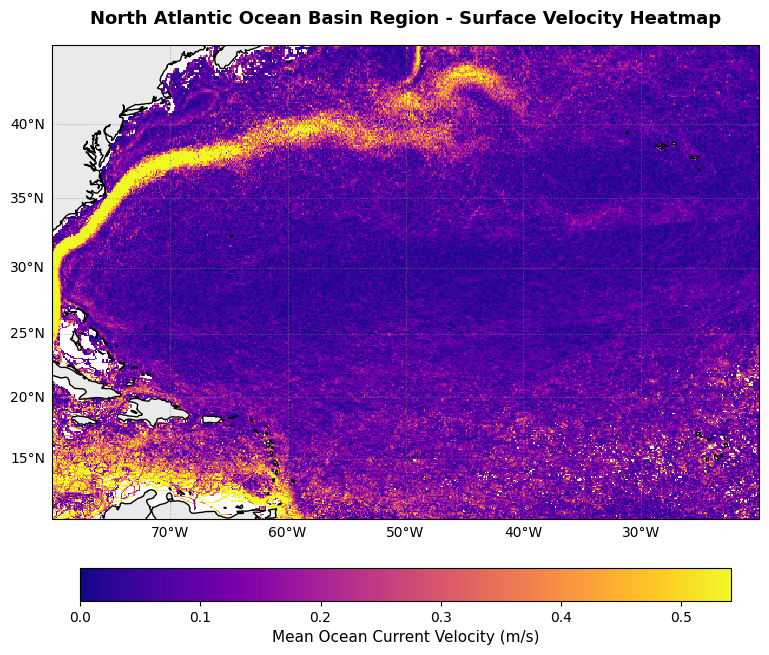

In [7]:
#-----------------------------------------------------------
# VISUALIZATION: NEAR-SURFACE CURRENT VELOCITY HEATMAP
#-----------------------------------------------------------
"""
Maps ocean surface current speeds using our cleaned drifter data.
Averages the directional flow (east and north movement),
to reveal true overall water movement.
"""

plot_df = pd.DataFrame({
    'lon': df['lon'],
    'lat': df['lat'],
    've': df['ve'],
    'vn': df['vn']
})

# Define a 0.1-degree grid resolution (approx. 11 km x 11 km) for given LAT and LON ranges
grid_res = 0.1
lon_bins = np.arange(LON_MIN, LON_MAX + grid_res, grid_res)
lat_bins = np.arange(LAT_MIN, LAT_MAX + grid_res, grid_res)

# Assign each observation point into its corresponding geographic grid cell
plot_df['lon_bin'] = pd.cut(plot_df['lon'], bins=lon_bins, labels=lon_bins[:-1]).astype(float)
plot_df['lat_bin'] = pd.cut(plot_df['lat'], bins=lat_bins, labels=lat_bins[:-1]).astype(float)

# Average ve and vn separately inside each cell
grid_ve = plot_df.groupby(['lat_bin', 'lon_bin'])['ve'].mean().unstack()
grid_vn = plot_df.groupby(['lat_bin', 'lon_bin'])['vn'].mean().unstack()

# Calculate net current speed magnitude
grid_speed = np.sqrt(grid_ve**2 + grid_vn**2)

# Generate the visualisation
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#eaeaea', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=3)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

rec_vmax = float(np.nanpercentile(grid_speed.values, 98))
mesh = ax.pcolormesh(
    grid_speed.columns, grid_speed.index, grid_speed.values,
    cmap='plasma', transform=ccrs.PlateCarree(), shading='auto',
    vmin=0, vmax=rec_vmax, zorder=1
)
print('Maximum velocity:',rec_vmax,'m/s')

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7)
cbar.set_label('Mean Ocean Current Velocity (m/s)', fontsize=11)

# Figure Title
plt.title(
    f"{region_name} Region - Surface Velocity Heatmap",
    fontsize=13,
    pad=15,
    weight="bold",
)

plt.show()

12.852352142333984 to 28.553752899169922


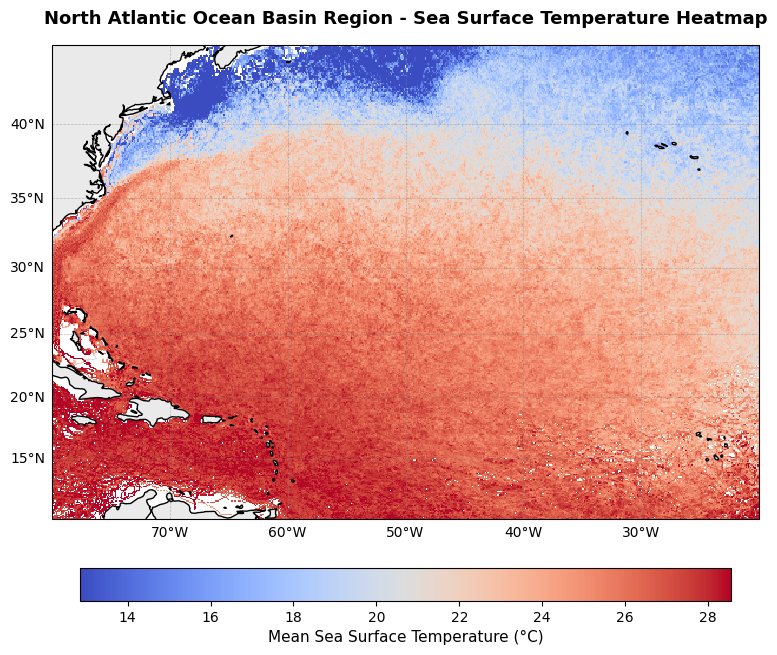

In [8]:
#-----------------------------------------------------------
# VISUALIZATION: SEA SURFACE TEMPERATURE HEATMAP
#-----------------------------------------------------------
"""
Maps sea surface temperatures across the region using our cleaned drifter data.
"""

sst = df['temp']

# Define a 0.1-degree grid resolution (approx. 11 km x 11 km boxes) for given LAT and LON ranges
grid_res = 0.1
lon_bins = np.arange(LON_MIN, LON_MAX + grid_res, grid_res)
lat_bins = np.arange(LAT_MIN, LAT_MAX + grid_res, grid_res)

plot_df = pd.DataFrame({
    'lon': df['lon'],
    'lat': df['lat'],
    'sst': sst
})

# Assign each observation point into its corresponding geographic grid cell
plot_df['lon_bin'] = pd.cut(plot_df['lon'], bins=lon_bins, labels=lon_bins[:-1]).astype(float)
plot_df['lat_bin'] = pd.cut(plot_df['lat'], bins=lat_bins, labels=lat_bins[:-1]).astype(float)

# Calculate average SST inside each grid box
grid_sst = plot_df.groupby(['lat_bin', 'lon_bin'])['sst'].mean().unstack()

# Generate the visualisation
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#eaeaea', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=3)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

rec_vmin = float(np.nanpercentile(grid_sst.values, 2))
rec_vmax = float(np.nanpercentile(grid_sst.values, 98))
print(rec_vmin, 'to', rec_vmax)

mesh = ax.pcolormesh(
    grid_sst.columns, grid_sst.index, grid_sst.values,
    cmap='coolwarm', transform=ccrs.PlateCarree(), shading='auto',
    vmin=rec_vmin, vmax=rec_vmax, zorder=1
)

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7)
cbar.set_label('Mean Sea Surface Temperature (°C)', fontsize=11)

# Figure Title
plt.title(
    f"{region_name} Region - Sea Surface Temperature Heatmap",
    fontsize=13,
    pad=15,
    weight="bold",
)

plt.show()

Selected n_clusters = 5 based on BIC relative gain threshold.



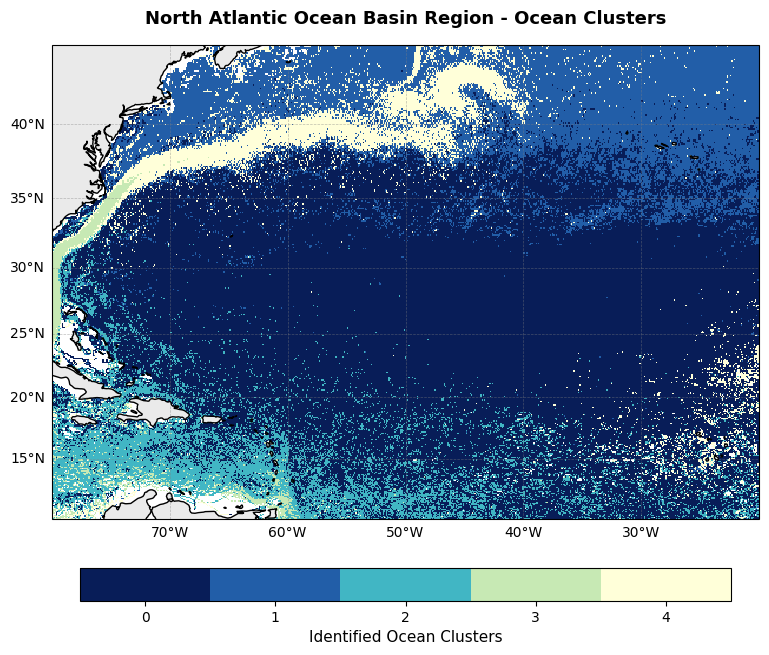



                                     Ocean Cluster Profiles

         n_cells  ve_mean  vn_mean  speed_mean   sst_mean  sst_std  confidence  share_%
cluster                                                                                
0         124878   -0.046    0.001       0.072  24.851999    1.984       0.875   64.181
1          33463    0.049   -0.007       0.088  17.944000    3.707       0.799   17.198
2          20371   -0.188    0.040       0.247  27.556000    0.798       0.804   10.470
3           2993   -0.077    0.437       0.793  27.410999    1.067       0.874    1.538
4          12866    0.180    0.030       0.320  20.620001    3.868       0.862    6.612


In [ ]:
#-----------------------------------------------------------
# UNSUPERVISED LEARNING: DYNAMIC GMM OCEAN CLUSTERING
#-----------------------------------------------------------
"""
Groups grid cells into distinct physical 'Ocean Clusters' based on local velocity
vector components (ve, vn) and temperature (sst).
Automatically evaluates candidate state counts via Bayesian Information Criterion (BIC) and
selects the optimal number of states and describes its characteristics
"""

# 1. Feature Aggregation
grid_features = pd.DataFrame({
    'mean_ve': grid_ve.stack(),
    'mean_vn': grid_vn.stack(),
    'mean_sst': grid_sst.stack()
}).reset_index()

# Filter out unvisited or incomplete grid cells
valid_cells = grid_features.dropna().copy()
X = valid_cells[['mean_ve', 'mean_vn', 'mean_sst']].values

# Scale features so coordinates (degrees) and velocities (m/s) are weighted equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Dynamic Hyperparameter Tuning via BIC
k_candidates = [2, 3, 4, 5, 6, 7, 8, 10, 12]

bics = [
    GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X_scaled).bic(X_scaled)
    for k in k_candidates
]

# Calculate relative BIC gain from increasing k
relative_gains = [(bics[i-1] - bics[i]) / bics[i-1] for i in range(1, len(bics))]
threshold = 0.01  # To stop when relative BIC improvement drops below 1%

# Automated cluster count selection based on diminishing BIC relative gains
n_clusters = k_candidates[-1]
for i, gain in enumerate(relative_gains):
    if gain < threshold:
        n_clusters = k_candidates[i]
        break

print(f"Selected n_clusters = {n_clusters} based on BIC relative gain threshold.\n")

# 3. Refit GMM with the n_clusters and assign cluster on scaled features.
best_gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
valid_cells['cluster'] = best_gmm.fit_predict(X_scaled)
grid_clusters = valid_cells.pivot(index='lat_bin', columns='lon_bin', values='cluster')

# Generate the visualisation
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#eaeaea', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=3)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap = plt.get_cmap('YlGnBu_r', n_clusters)
mesh = ax.pcolormesh(
    grid_clusters.columns, grid_clusters.index, grid_clusters.values,
    cmap=cmap, transform=ccrs.PlateCarree(), shading='auto',
    vmin=-0.5, vmax=n_clusters - 0.5, zorder=1
)

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7, ticks=range(n_clusters))
cbar.set_label('Identified Ocean Clusters', fontsize=11)

plt.title(f"{region_name} Region - Ocean Clusters",
          fontsize=13, pad=15, weight='bold')

plt.show()
print()

# Profile each ocean cluster in physical units
valid_cells['speed'] = np.hypot(valid_cells['mean_ve'], valid_cells['mean_vn'])
valid_cells['confidence'] = best_gmm.predict_proba(X_scaled).max(axis=1)

profile = valid_cells.groupby('cluster').agg(
    n_cells=('cluster', 'size'), # number of 0.1 x 0.1 grids
    ve_mean=('mean_ve', 'mean'),
    vn_mean=('mean_vn', 'mean'),
    speed_mean=('speed', 'mean'), # mean value of speed: magnitude of ve and vn
    sst_mean=('mean_sst', 'mean'),
    sst_std=('mean_sst', 'std'),
    confidence=('confidence', 'mean'), # average assignment certainty of all cells in that cluster
)

profile['share_%'] = 100 * profile['n_cells'] / profile['n_cells'].sum()

print('\n',' ' * 35,'Ocean Cluster Profiles\n')
print(profile.round(3).sort_values('cluster', ascending=True).to_string())

##Interpretation of Identified Ocean Clusters

### Cluster 0: Central Subtropical Basin / Sargasso Sea Region ("Low-Velocity / High-Retention Zone")
* Key Metrics: Mean Speed = $0.072$ m/s | Mean SST = $24.85$°C | Basin Share = $64.18$%
* Flow Dynamics: Sluggish westward zonal drift (${v}_e = -0.046$ m/s) with near-zero meridional movement (${v}_n = 0.001$ m/s), resulting in a minimal net current speed
* Data-Driven Context: Represents the low-energy core of the North Atlantic Subtropical Gyre, covering nearly two-thirds of the spatial basin. The combination of minimal horizontal velocity, high classification confidence (0.875), and low thermal variance ($\sigma_{\text{SST}} = 1.98^\circ\text{C}$) reflects stable, stagnant surface waters. Empirically, drifters entering this cluster experience minimal directional push and long residence times, identifying this regime as the ocean's primary long-term particle accumulation and retention zone.

### Cluster 1: Northern & Eastern Basin Flanks ("Cooler / Moderate-Drift Zone")
* Key Metrics: Mean Speed = 0.088 m/s | Mean SST = 17.94°C | Basin Share = 17.20%
* Flow Dynamics: Weak eastward zonal drift (${v}_e = 0.049$ m/s) coupled with a minor equatorward component (${v}_n = -0.007$ m/s), yielding a slow net current speed
* Data-Driven Context: Spans the cooler northern mid-latitudes and eastern basin (${\text{SST}} = 17.94^\circ\text{C}$). The high thermal standard deviation ($\sigma_{\text{SST}} = 3.71^\circ\text{C}$) reflects strong seasonal temperature fluctuations and mixing along subpolar boundary fronts and southward-flowing currents.

### Cluster 2: North Equatorial Current ("Warm Tropical Feeder Lane")
* Key Metrics: Mean Speed = 0.247 m/s | Mean SST = 27.56°C | Basin Share = 10.47%
* Flow Dynamics: Steady westward drift (${v}_e = -0.188$ m/s) with a slight northward drift (${v}_n = 0.040$ m/s)
* Data-Driven Context: Defined by high surface temperatures (${\text{SST}} = 27.56^\circ\text{C}$) and exceptional thermal uniformity ($\sigma_{\text{SST}} = 0.80^\circ\text{C}$), this cluster captures the trade-wind-driven North Equatorial Current (NEC), acting as a continuous tropical transport corridor that carries buoyant surface material westward from the African coast toward the Caribbean and Gulf Stream inflow regions.

### Cluster 3: Gulf Stream High-Velocity Core ("Western Boundary Express Jet")
* Key Metrics: Mean Speed = 0.793 m/s | Mean SST = 27.41°C | Basin Share = 1.54%
* Flow Dynamics: Intense northward jet  (${v}_n = 0.437$ m/s) with a slight westward boundary compression (${v}_e = -0.077$ m/s), generating the highest mean net speed in the basin.
* Data-Driven Context: Captures the narrow, high-energy jet of the Gulf Stream along the North American continental seaboard. Although accounting for only 1.54% of spatial grid cells, its high classification certainty (0.874) and elevated thermal profile (${\text{SST}} = 27.41^\circ\text{C}$) mark it as a high-velocity transit channel that rapidly flushes surface water and debris poleward.

### Cluster 4: Mid-Latitude Extension & Upwelling Margins ("Eastward Transit Corridor")
* Key Metrics: Mean Speed = 0.320 m/s | Mean SST = 20.62°C | Basin Share = 6.61%
* Flow Dynamics: Dominant positive zonal velocity (${v}_e = 0.180$ m/s) accompanied by weak northward drift (${v}_n = 0.030$ m/s).
* Data-Driven Context: Primarily represents the North Atlantic Current (NAC) extension where western boundary flows detach from the coast and bend eastward across mid-latitudes ($35^\circ\text{N} - 45^\circ\text{N}$), characterized by high thermal variability ($\sigma_{\text{SST}} = 3.87^\circ\text{C}$).




In [ ]:
valid_cells.head()

,lat_bin,lon_bin,mean_ve,mean_vn,mean_sst,cluster,speed,confidence
0,10.0,-80.0,0.427110,0.439397,27.901667,3,0.612774,0.896047
1,10.0,-79.9,-0.146505,-0.182500,26.980000,2,0.234030,0.948941
2,10.0,-79.8,0.687028,0.330460,27.493000,3,0.762372,0.786667
3,10.0,-79.7,0.443297,0.164103,27.695000,4,0.472696,0.652847
4,10.0,-79.6,0.984850,0.340690,27.271999,3,1.042113,0.963096


--- MARKOV TRANSITION PROBABILITY MATRIX ---
next_cluster      0      1      2      3      4
cluster                                        
0             0.961  0.022  0.013  0.000  0.004
1             0.099  0.851  0.002  0.000  0.048
2             0.277  0.007  0.694  0.014  0.008
3             0.009  0.002  0.113  0.794  0.082
4             0.066  0.175  0.006  0.006  0.747
--------------------------------------------------


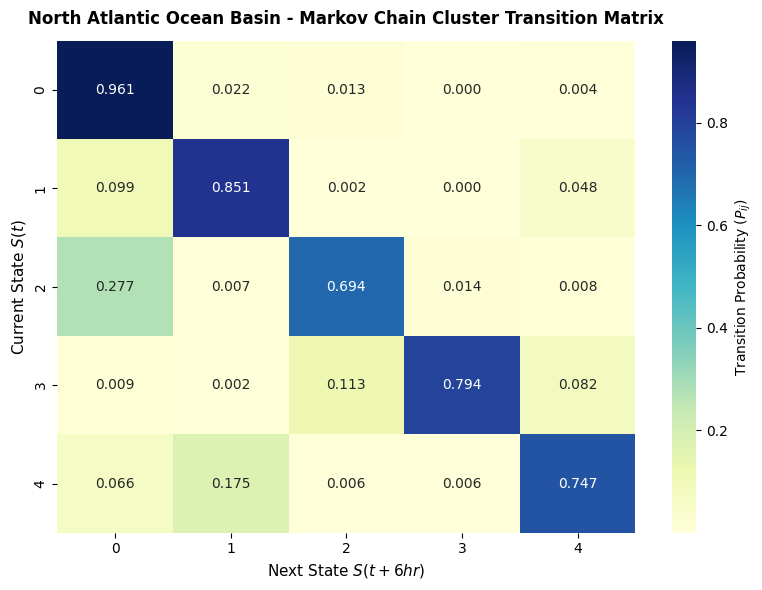

In [ ]:
#-----------------------------------------------------------
# MARKOV CHAIN: DRIFTER CLUSTER TRANSITION ANALYSIS
#-----------------------------------------------------------
"""
Markov Transition Probability Matrix to model drifter movement between clusters.
"""

# Define a 0.1-degree grid resolution (approx. 11 km x 11 km boxes) for given LAT and LON ranges
grid_res = 0.1
lon_bins = np.arange(LON_MIN, LON_MAX + grid_res, grid_res)
lat_bins = np.arange(LAT_MIN, LAT_MAX + grid_res, grid_res)

df['lon_bin'] = pd.cut(df['lon'], bins=lon_bins, labels=lon_bins[:-1]).astype(float)
df['lat_bin'] = pd.cut(df['lat'], bins=lat_bins, labels=lat_bins[:-1]).astype(float)

# mapping each drifter's location to its assigned ocean regime in df
if 'cluster' in df.columns:
    df = df.drop(columns=['cluster'])

df = df.merge(
    valid_cells[['lat_bin', 'lon_bin', 'cluster']],
    on=['lat_bin', 'lon_bin'],
    how='left'
)

# Sorts drifter observations
df = df.sort_values(by=['id', 'time']).reset_index(drop=True)
# Look ahead 1 time step (6 hrs) within each drifter's track to find its next ocean regime
# and add it onto df into the 'next_cluster' column
df['next_cluster'] = df.groupby('id')['cluster'].shift(-1)

# Filters out incomplete transitions and converts valid cluster labels to integers
transitions_df = df.dropna(subset=['cluster', 'next_cluster']).copy()
transitions_df['cluster'] = transitions_df['cluster'].astype(int)
transitions_df['next_cluster'] = transitions_df['next_cluster'].astype(int)

# Reindexes rows and columns across range(n_clusters) to maintain square matrix dimensions.
transition_matrix = pd.crosstab(
    transitions_df['cluster'],
    transitions_df['next_cluster'],
    normalize='index'
).reindex(index=range(n_clusters), columns=range(n_clusters), fill_value=0)

print("--- MARKOV TRANSITION PROBABILITY MATRIX ---")
print(transition_matrix.round(3))
print("-" * 50)

plt.figure(figsize=(8, 6))
sns.heatmap(
    transition_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={'label': r'Transition Probability ($P_{ij}$)'}
)

plt.title(f"{region_name} - Markov Chain Cluster Transition Matrix", fontsize=12, pad=12, weight='bold')
plt.xlabel(r"Next State $S(t + 6hr)$", fontsize=11)
plt.ylabel(r"Current State $S(t)$", fontsize=11)
plt.tight_layout()
plt.show()